In [6]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# For data augmentation
import albumentations as A


In [7]:
# ============================================================
# DATASET PATHS
# ============================================================

# Root dataset directory
DATASET_PATH = "dataset/images"

# CT and MRI training folders
CT_PATH = os.path.join(DATASET_PATH, "trainA")
MRI_PATH = os.path.join(DATASET_PATH, "trainB")

print("CT path:", CT_PATH)
print("MRI path:", MRI_PATH)


CT path: dataset/images/trainA
MRI path: dataset/images/trainB


In [8]:
import os

print("CT_PATH:", CT_PATH)
print("MRI_PATH:", MRI_PATH)

print("CT files:", len(os.listdir(CT_PATH)))
print("MRI files:", len(os.listdir(MRI_PATH)))

print("First CT file:", sorted(os.listdir(CT_PATH))[:5])
print("First MRI file:", sorted(os.listdir(MRI_PATH))[:5])


CT_PATH: dataset/images/trainA
MRI_PATH: dataset/images/trainB
CT files: 1742
MRI files: 1744
First CT file: ['ct1.png', 'ct1001.png', 'ct1002.png', 'ct1003.png', 'ct1004.png']
First MRI file: ['mri1.jpg', 'mri1001.jpg', 'mri1002.jpg', 'mri1003.jpg', 'mri1004.jpg']


In [9]:
# ============================================================
# CREATE CORRECT CT–MRI PAIR MAPPING USING FILE IDS
# ============================================================

import re

def extract_id(filename):
    """Extract numeric ID from filename"""
    return int(re.findall(r'\d+', filename)[0])

# Get file lists
ct_files = os.listdir(CT_PATH)
mri_files = os.listdir(MRI_PATH)

# Create dictionaries
ct_dict = {extract_id(f): f for f in ct_files}
mri_dict = {extract_id(f): f for f in mri_files}

# Find common IDs (valid pairs)
common_ids = sorted(set(ct_dict.keys()) & set(mri_dict.keys()))

print("Total CT:", len(ct_files))
print("Total MRI:", len(mri_files))
print("Valid paired samples:", len(common_ids))


Total CT: 1742
Total MRI: 1744
Valid paired samples: 1705


CT shape: (512, 512)
MRI shape: (280, 212)


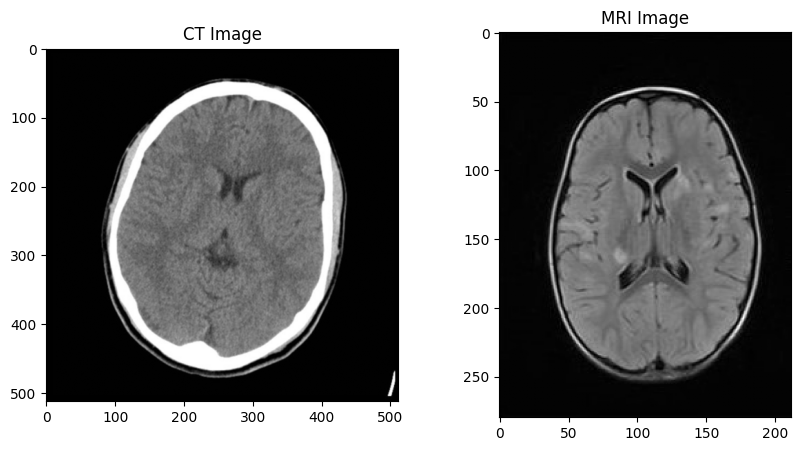

In [10]:
# ============================================================
# LOAD A CORRECTLY MATCHED PAIR
# ============================================================

sample_id = common_ids[0]

ct_img = cv2.imread(os.path.join(CT_PATH, ct_dict[sample_id]), cv2.IMREAD_GRAYSCALE)
mri_img = cv2.imread(os.path.join(MRI_PATH, mri_dict[sample_id]), cv2.IMREAD_GRAYSCALE)

print("CT shape:", ct_img.shape)
print("MRI shape:", mri_img.shape)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct_img, cmap="gray")
plt.title("CT Image")

plt.subplot(1,2,2)
plt.imshow(mri_img, cmap="gray")
plt.title("MRI Image")

plt.show()


# Creating Correct CT–MRI Pairs

In this step, we ensured proper anatomical correspondence between CT and MRI images. The dataset stores CT and MRI slices using different naming conventions (e.g., ct1.png and mri1.jpg), so direct filename matching or sorted ordering would lead to incorrect pairings.

To address this, we extracted the numeric identifier from each filename and created mappings between CT and MRI images using these IDs. Only those images that shared a common identifier were retained, ensuring that each CT image was paired with its corresponding MRI slice.

Images without a matching counterpart in the other modality were excluded from further processing. This step guarantees that subsequent preprocessing, augmentation, and model training operate on correctly aligned multi-modal anatomical data.

In [11]:
# ============================================================
# NORMALIZATION FUNCTION
# Normalizes each modality independently to range [0,1]
# ============================================================

def normalize_image(img):
    """
    Convert image to float and scale values between 0 and 1.
    This is done separately for CT and MRI because their
    intensity distributions are fundamentally different.
    """
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)


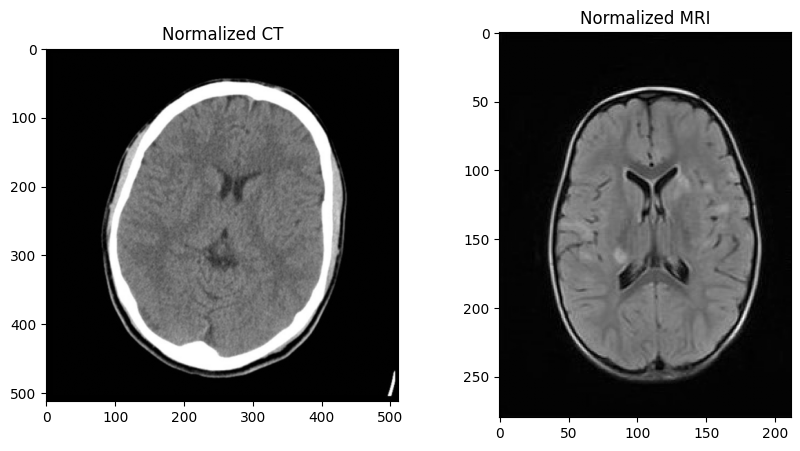

CT range: 0.0 to 1.0
MRI range: 0.0 to 1.0


In [12]:
# ============================================================
# TEST NORMALIZATION ON ONE PAIR
# ============================================================

ct_norm = normalize_image(ct_img)
mri_norm = normalize_image(mri_img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct_norm, cmap="gray")
plt.title("Normalized CT")

plt.subplot(1,2,2)
plt.imshow(mri_norm, cmap="gray")
plt.title("Normalized MRI")

plt.show()

print("CT range:", ct_norm.min(), "to", ct_norm.max())
print("MRI range:", mri_norm.min(), "to", mri_norm.max())


CT and MRI images were normalized independently using min-max scaling to ensure each modality retained its unique intensity characteristics while bringing pixel values into a consistent range for stable neural network training.

In [13]:
# ============================================================
# RESIZE & ALIGNMENT FUNCTION
# Ensures CT and MRI have identical spatial dimensions
# ============================================================

def resize_pair(ct, mri, size=(256, 256)):
    """
    Resize CT and MRI images to a common resolution.

    This step is necessary because deep learning models require
    fixed-size inputs, and resizing ensures both modalities
    remain spatially aligned for accurate multi-modal learning.
    """
    ct_resized = cv2.resize(ct, size, interpolation=cv2.INTER_AREA)
    mri_resized = cv2.resize(mri, size, interpolation=cv2.INTER_AREA)
    
    return ct_resized, mri_resized


CT resized shape: (256, 256)
MRI resized shape: (256, 256)


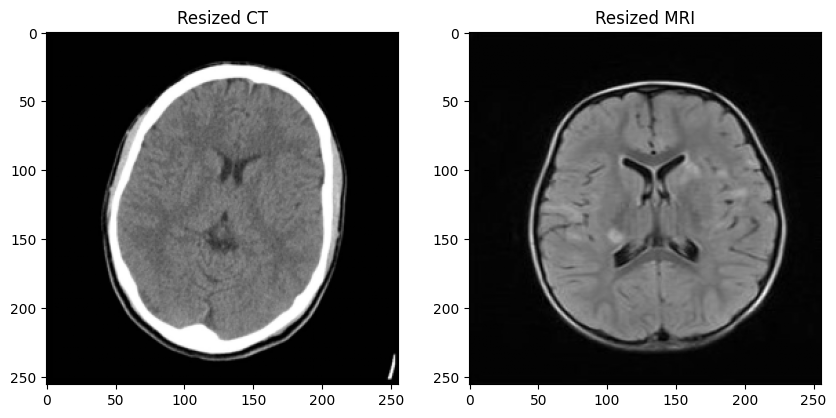

In [14]:
# ============================================================
# TEST RESIZE FUNCTION
# ============================================================

ct_resized, mri_resized = resize_pair(ct_norm, mri_norm)

print("CT resized shape:", ct_resized.shape)
print("MRI resized shape:", mri_resized.shape)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct_resized, cmap="gray")
plt.title("Resized CT")

plt.subplot(1,2,2)
plt.imshow(mri_resized, cmap="gray")
plt.title("Resized MRI")

plt.show()


To ensure compatibility with deep learning models, CT and MRI images were resized to a uniform spatial resolution. This step guarantees that both modalities share identical dimensions, preserving anatomical correspondence while enabling efficient batch processing during model training.

In [15]:
# ============================================================
# DATA AUGMENTATION PIPELINE (UPDATED - USING AFFINE)
# ============================================================

"""
This augmentation pipeline applies synchronized transformations
to both CT and MRI images to maintain anatomical correspondence.

Includes:
- Spatial distortions (rotation, scaling, translation)
- Intensity variations
"""

augment = A.Compose([
    
    # Spatial distortions using Affine transform
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(0.05, 0.05),
        rotate=(-10, 10),
        p=0.5
    ),
    
    # Intensity variation
    A.RandomBrightnessContrast(p=0.5),
    
], additional_targets={'mri': 'image'})


In [16]:
# ============================================================
# RANDOM NOISE INJECTION
# ============================================================

def add_noise(img, noise_level=0.02):
    """
    Adds Gaussian noise to simulate scanner noise.
    Improves robustness of anomaly detection models.
    """
    noise = np.random.normal(0, noise_level, img.shape)
    noisy_img = img + noise
    return np.clip(noisy_img, 0, 1)


In [18]:
# ============================================================
# APPLY AUGMENTATION TO CT–MRI PAIRS
# ============================================================

def augment_pair(ct, mri):
    
    # Apply paired augmentation
    augmented = augment(image=ct, mri=mri)
    
    ct_aug = augmented["image"]
    mri_aug = augmented["mri"]
    
    # Add noise separately to each modality
    ct_aug = add_noise(ct_aug)
    mri_aug = add_noise(mri_aug)
    
    return ct_aug, mri_aug


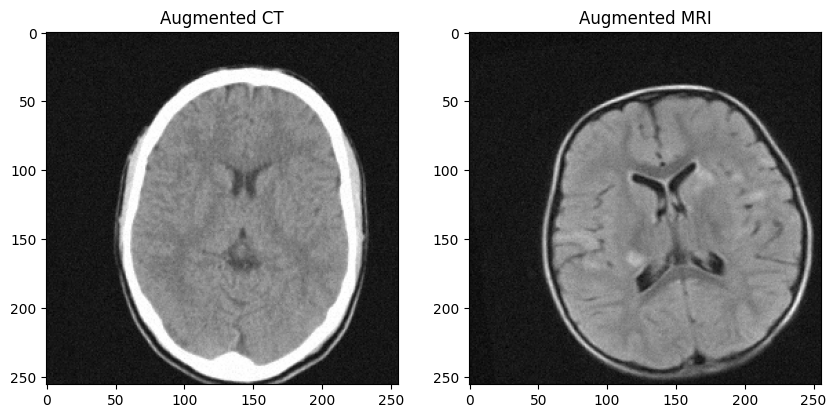

In [19]:
# ============================================================
# TEST AUGMENTATION PIPELINE
# ============================================================

ct_aug, mri_aug = augment_pair(ct_resized, mri_resized)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct_aug, cmap="gray")
plt.title("Augmented CT")

plt.subplot(1,2,2)
plt.imshow(mri_aug, cmap="gray")
plt.title("Augmented MRI")

plt.show()


To improve model robustness and generalization, paired data augmentation was applied to CT and MRI images. Spatial transformations such as rotation, scaling, and shifting were applied synchronously to both modalities to preserve anatomical alignment. Additionally, intensity variations and Gaussian noise injection were introduced to simulate real-world imaging variability and scanner noise.

In [20]:
# ============================================================
# COMPLETE PREPROCESSING PIPELINE FUNCTION
# ============================================================

def preprocess_pair(ct, mri):
    """
    Complete preprocessing pipeline for paired CT–MRI images.

    Steps performed:
    1. Independent normalization of CT and MRI
    2. Resize and spatial alignment
    3. Paired data augmentation using affine transforms
    4. Random noise injection

    Returns:
        Preprocessed CT and MRI images ready for model input.
    """
    
    # Step 1: Normalize independently
    ct = normalize_image(ct)
    mri = normalize_image(mri)
    
    # Step 2: Resize & align
    ct, mri = resize_pair(ct, mri)
    
    # Step 3: Apply paired augmentation
    augmented = augment(image=ct, mri=mri)
    ct = augmented["image"]
    mri = augmented["mri"]
    
    # Step 4: Add noise injection
    ct = add_noise(ct)
    mri = add_noise(mri)
    
    return ct, mri


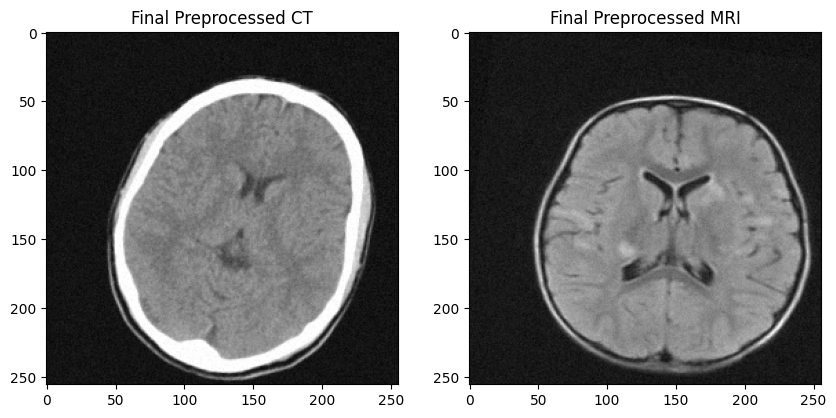

CT range: 0.0 to 1.0
MRI range: 0.0 to 0.9674240936695536


In [21]:
# ============================================================
# TEST COMPLETE PREPROCESSING PIPELINE
# ============================================================

ct_final, mri_final = preprocess_pair(ct_img, mri_img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct_final, cmap="gray")
plt.title("Final Preprocessed CT")

plt.subplot(1,2,2)
plt.imshow(mri_final, cmap="gray")
plt.title("Final Preprocessed MRI")

plt.show()

print("CT range:", ct_final.min(), "to", ct_final.max())
print("MRI range:", mri_final.min(), "to", mri_final.max())


A comprehensive preprocessing pipeline was developed for paired CT and MRI brain images. Each modality was independently normalized to account for differing intensity distributions. The images were then resized to a common spatial resolution to ensure anatomical alignment. Paired data augmentation was applied using affine transformations to preserve spatial correspondence across modalities, along with intensity variations to simulate imaging variability. Finally, Gaussian noise injection was introduced to enhance model robustness against scanner noise. Due to interpolation during affine transformations and intensity augmentations, the final pixel values may not span the full [0,1] range. This is expected and does not affect model training.

In [22]:
# ============================================================
# IMPORT PYTORCH LIBRARIES
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


In [23]:
# ============================================================
# CONVOLUTIONAL ENCODER
# Learns modality-specific features
# ============================================================

class Encoder(nn.Module):
    def __init__(self, latent_dim=256):
        super(Encoder, self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),   # 256 → 128
            nn.ReLU(),
            
            nn.Conv2d(32, 64, 4, 2, 1),  # 128 → 64
            nn.ReLU(),
            
            nn.Conv2d(64, 128, 4, 2, 1), # 64 → 32
            nn.ReLU(),
            
            nn.Conv2d(128, 256, 4, 2, 1),# 32 → 16
            nn.ReLU()
        )
        
        self.fc = nn.Linear(256*16*16, latent_dim)
    
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        latent = self.fc(x)
        return latent


In [24]:
# ============================================================
# DECODER NETWORK
# Reconstructs CT or MRI from shared latent space
# ============================================================

class Decoder(nn.Module):
    def __init__(self, latent_dim=256):
        super(Decoder, self).__init__()
        
        self.fc = nn.Linear(latent_dim, 256*16*16)
        
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Sigmoid()
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 16, 16)
        x = self.deconv(x)
        return x


In [25]:
# ============================================================
# CORRECT MULTIMODAL CONVOLUTIONAL AUTOENCODER
# Separate decoders for CT and MRI
# ============================================================

class MultiModalAE(nn.Module):
    def __init__(self, latent_dim=256):
        super(MultiModalAE, self).__init__()
        
        # Encoders
        self.ct_encoder = Encoder(latent_dim)
        self.mri_encoder = Encoder(latent_dim)
        
        # Fusion layer (better than simple averaging)
        self.fusion = nn.Linear(latent_dim * 2, latent_dim)
        
        # Separate decoders
        self.ct_decoder = Decoder(latent_dim)
        self.mri_decoder = Decoder(latent_dim)
    
    def forward(self, ct, mri):
        
        ct_latent = self.ct_encoder(ct)
        mri_latent = self.mri_encoder(mri)
        
        # Concatenate and fuse
        combined = torch.cat([ct_latent, mri_latent], dim=1)
        shared_latent = self.fusion(combined)
        
        # Separate reconstructions
        ct_recon = self.ct_decoder(shared_latent)
        mri_recon = self.mri_decoder(shared_latent)
        
        return ct_recon, mri_recon, ct_latent, mri_latent, shared_latent


In [26]:
def ae_loss(ct, ct_recon, mri, mri_recon):
    
    loss_ct = F.mse_loss(ct_recon, ct)
    loss_mri = F.mse_loss(mri_recon, mri)
    
    return loss_ct + loss_mri


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiModalAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 20


In [28]:
def show_reconstructions(model, dataset, device, epoch):
    
    model.eval()
    
    ct, mri = dataset[0]
    
    ct = ct.unsqueeze(0).to(device)
    mri = mri.unsqueeze(0).to(device)
    
    with torch.no_grad():
        ct_recon, mri_recon, *_ = model(ct, mri)
    
    plt.figure(figsize=(10,4))
    
    plt.subplot(2,2,1)
    plt.imshow(ct.cpu().squeeze(), cmap="gray")
    plt.title("Original CT")
    
    plt.subplot(2,2,2)
    plt.imshow(ct_recon.cpu().squeeze(), cmap="gray")
    plt.title(f"CT Recon Epoch {epoch}")
    
    plt.subplot(2,2,3)
    plt.imshow(mri.cpu().squeeze(), cmap="gray")
    plt.title("Original MRI")
    
    plt.subplot(2,2,4)
    plt.imshow(mri_recon.cpu().squeeze(), cmap="gray")
    plt.title(f"MRI Recon Epoch {epoch}")
    
    plt.show()


In [30]:
# ============================================================
# PYTORCH DATASET FOR PAIRED CT–MRI IMAGES
# ============================================================

from torch.utils.data import Dataset

class CTMRIDataset(Dataset):
    def __init__(self, ct_dict, mri_dict, common_ids):
        """
        Args:
            ct_dict: Mapping of ID → CT filename
            mri_dict: Mapping of ID → MRI filename
            common_ids: List of valid paired IDs
        """
        self.ct_dict = ct_dict
        self.mri_dict = mri_dict
        self.ids = common_ids
    
    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        
        sample_id = self.ids[idx]
        
        # Load images
        ct = cv2.imread(os.path.join(CT_PATH, self.ct_dict[sample_id]), 0)
        mri = cv2.imread(os.path.join(MRI_PATH, self.mri_dict[sample_id]), 0)
        
        # Apply preprocessing pipeline
        ct, mri = preprocess_pair(ct, mri)
        
        # Convert to tensors
        ct = torch.tensor(ct, dtype=torch.float32).unsqueeze(0)
        mri = torch.tensor(mri, dtype=torch.float32).unsqueeze(0)
        
        return ct, mri


In [31]:
# ============================================================
# CREATE DATA LOADER
# ============================================================

from torch.utils.data import DataLoader

dataset = CTMRIDataset(ct_dict, mri_dict, common_ids)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

print("Total samples:", len(dataset))


Total samples: 1705


Epoch 1/20, Loss: 23.1699
Epoch 2/20, Loss: 15.2039
Epoch 3/20, Loss: 12.9986
Epoch 4/20, Loss: 11.1967
Epoch 5/20, Loss: 10.1472


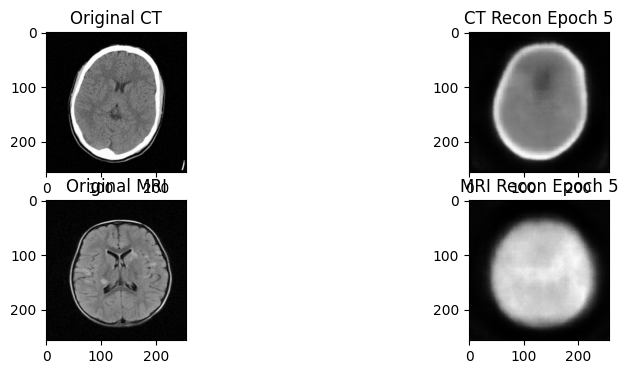

Epoch 6/20, Loss: 9.6324
Epoch 7/20, Loss: 9.2491
Epoch 8/20, Loss: 8.8937
Epoch 9/20, Loss: 8.5891
Epoch 10/20, Loss: 8.3099


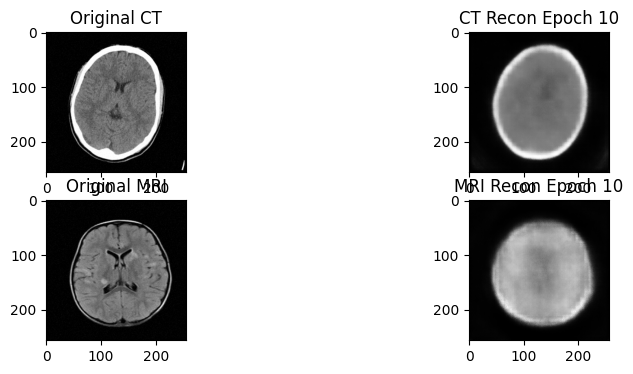

Epoch 11/20, Loss: 7.9952
Epoch 12/20, Loss: 7.7809
Epoch 13/20, Loss: 7.5340
Epoch 14/20, Loss: 7.2474
Epoch 15/20, Loss: 7.1558


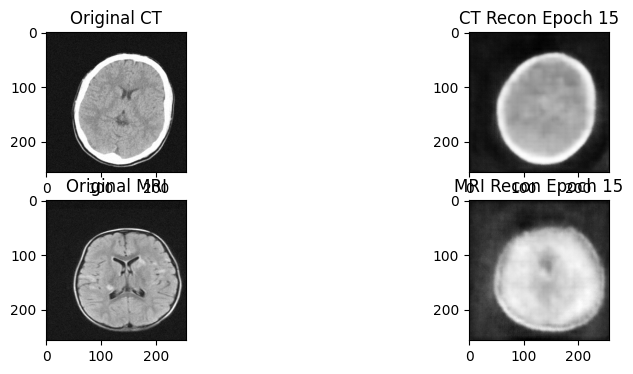

Epoch 16/20, Loss: 7.0115
Epoch 17/20, Loss: 6.7467
Epoch 18/20, Loss: 6.6168
Epoch 19/20, Loss: 6.4360
Epoch 20/20, Loss: 6.3190


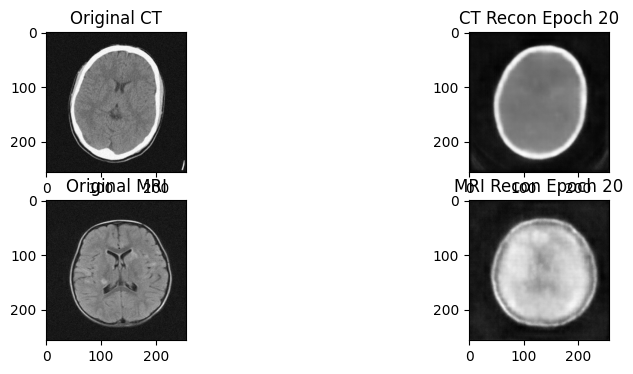

In [32]:
for epoch in range(epochs):
    
    model.train()
    total_loss = 0
    
    for ct, mri in dataloader:
        
        ct = ct.to(device)
        mri = mri.to(device)
        
        optimizer.zero_grad()
        
        ct_recon, mri_recon, *_ = model(ct, mri)
        
        loss = ae_loss(ct, ct_recon, mri, mri_recon)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")
    
    # Show images every 5 epochs
    if (epoch + 1) % 5 == 0:
        show_reconstructions(model, dataset, device, epoch+1)


A joint multimodal convolutional autoencoder was developed to learn latent representations from paired CT and MRI brain images. Separate encoders were used to extract modality-specific features from each imaging modality, capturing unique structural and intensity characteristics. The encoded representations were then fused into a shared latent space to model cross-modal anatomical relationships. A common decoder reconstructed both CT and MRI images from this shared representation, enabling the model to learn both modality-specific and shared features essential for anomaly detection.

In [33]:
# ============================================================
# EXTRACT FEATURES FROM TRAINED CAE
# ============================================================

def extract_cae_features(model, dataloader, device):
    
    model.eval()
    
    ct_features = []
    mri_features = []
    shared_features = []
    
    with torch.no_grad():
        for ct, mri in dataloader:
            
            ct = ct.to(device)
            mri = mri.to(device)
            
            _, _, ct_latent, mri_latent, shared_latent = model(ct, mri)
            
            ct_features.append(ct_latent.cpu())
            mri_features.append(mri_latent.cpu())
            shared_features.append(shared_latent.cpu())
    
    ct_features = torch.cat(ct_features)
    mri_features = torch.cat(mri_features)
    shared_features = torch.cat(shared_features)
    
    return ct_features, mri_features, shared_features


In [34]:
ct_feats_cae, mri_feats_cae, shared_feats_cae = extract_cae_features(
    model, dataloader, device
)

print("CT Features Shape:", ct_feats_cae.shape)
print("MRI Features Shape:", mri_feats_cae.shape)
print("Shared Features Shape:", shared_feats_cae.shape)


CT Features Shape: torch.Size([1705, 256])
MRI Features Shape: torch.Size([1705, 256])
Shared Features Shape: torch.Size([1705, 256])


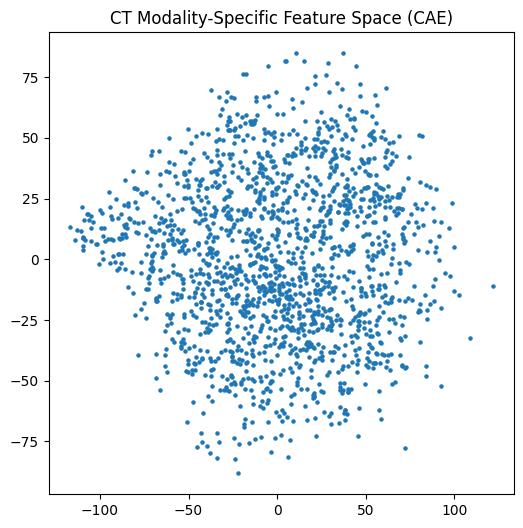

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
ct_reduced = pca.fit_transform(ct_feats_cae)

plt.figure(figsize=(6,6))
plt.scatter(ct_reduced[:,0], ct_reduced[:,1], s=5)
plt.title("CT Modality-Specific Feature Space (CAE)")
plt.show()


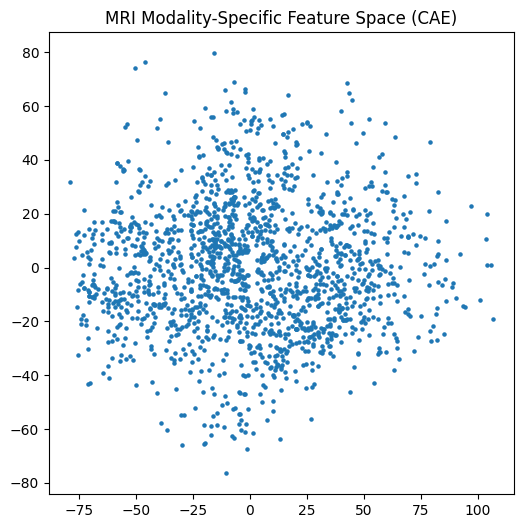

In [37]:
mri_reduced = pca.fit_transform(mri_feats_cae)

plt.figure(figsize=(6,6))
plt.scatter(mri_reduced[:,0], mri_reduced[:,1], s=5)
plt.title("MRI Modality-Specific Feature Space (CAE)")
plt.show()


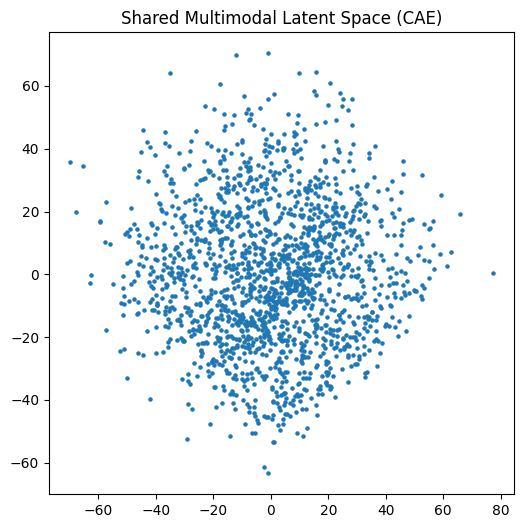

In [38]:
shared_reduced = pca.fit_transform(shared_feats_cae)

plt.figure(figsize=(6,6))
plt.scatter(shared_reduced[:,0], shared_reduced[:,1], s=5)
plt.title("Shared Multimodal Latent Space (CAE)")
plt.show()


In [39]:
latent_distance = torch.norm(
    ct_feats_cae - mri_feats_cae, dim=1
)

print("Average CT-MRI latent distance:",
      latent_distance.mean().item())


Average CT-MRI latent distance: 135.0652618408203


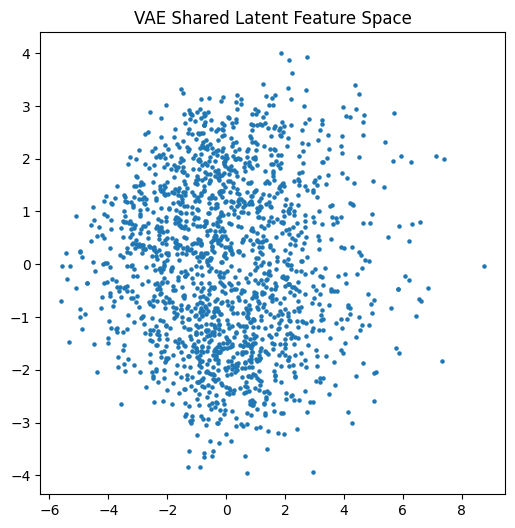

In [54]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(shared_feats_vae)

plt.figure(figsize=(6,6))
plt.scatter(reduced[:,0], reduced[:,1], s=5)
plt.title("VAE Shared Latent Feature Space")
plt.show()
